# Notebook for the house prices advanced regression kaggle competition

## Loading the data and the modules

In [4]:
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.proportion import std_prop
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
import pandas as pd
import numpy as np
import seaborn as sns

valid = pd.read_csv('test.csv')
init_train = pd.read_csv('train.csv')
X, y = init_train.drop(["Id", "SalePrice"], axis=1), init_train.SalePrice

## Data visualisation, discovery and initial cleaning
Of course, first step is to check the documentation if it exists, to have information about the columns that we have

#### Target information

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Axes: xlabel='SalePrice', ylabel='Count'>

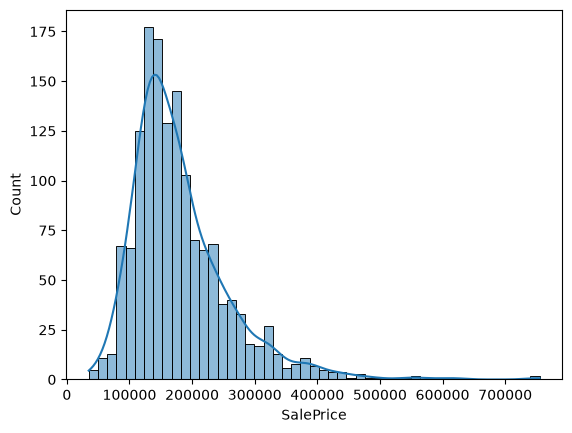

In [5]:
print(y.describe())
sns.histplot(y, kde=True)

#### Check the column types
Usefull for understanding our data and preparing encoding or

In [6]:
print(f"Dtypes counts : {X.dtypes.value_counts()}")
# Selecting the columns with number or not number types
num_cols = X.select_dtypes(include='number').columns
obj_cols = X.columns.difference(num_cols)
print(f"\nObject columns : {obj_cols}")
print(f"\nNumerical columns : {num_cols}")
# Take a look at the columns to see if there might be Dates that could be used
print(f"\nColumn names : {X.columns}")

Dtypes counts : str        43
int64      33
float64     3
Name: count, dtype: int64

Object columns : Index(['Alley', 'BldgType', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'BsmtQual', 'CentralAir', 'Condition1', 'Condition2',
       'Electrical', 'ExterCond', 'ExterQual', 'Exterior1st', 'Exterior2nd',
       'Fence', 'FireplaceQu', 'Foundation', 'Functional', 'GarageCond',
       'GarageFinish', 'GarageQual', 'GarageType', 'Heating', 'HeatingQC',
       'HouseStyle', 'KitchenQual', 'LandContour', 'LandSlope', 'LotConfig',
       'LotShape', 'MSZoning', 'MasVnrType', 'MiscFeature', 'Neighborhood',
       'PavedDrive', 'PoolQC', 'RoofMatl', 'RoofStyle', 'SaleCondition',
       'SaleType', 'Street', 'Utilities'],
      dtype='str')

Numerical columns : Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', '

#### Finding interesting features based on documentation
Important step, we then compare what we found to the scatter plots that are to follow
# TODO

Study of features makes it possible to combine together features that relates to the same part of the house or that have similarities.

In [7]:
n_uniq_description = {"MSSubClass":16, "MSZoning":8, "Street":2, "Alley":3, "LotShape":4, "LandContour":4, "Utilities":4, "LotConfig":5, "LandSlope":3, "Neighborhood":25, "Condition1":9, "Condition2":9, "BldgType":5, "HouseStyle":8, "OverallQual":10, "OverallCond":10, "RoofStyle":6, "RoofMatl":8, "Exterior1st":17, "Exterior2nd":17, "MasVnrType":5, "ExterQual":5, "ExterCond":5, "Foundation":6, "BsmtQual":6, "BsmtCond":6, "BsmtExposure":5, "BsmtFinType1":7, "BsmtFinType2":7, "Heating":6, "HeatingQC":5, "CentralAir":2, "Electrical":5, "KitchenQual":5, "Functional":8, "FireplaceQu":6, "GarageType":7, "GarageFinish":4, "GarageQual":6, "GarageCond":6, "PavedDrive":3, "PoolQC":5, "Fence":5, "MiscFeature":6, "SaleType":10, "SaleCondition":6}
for feat in obj_cols:
    print(feat)
    for uniq in X[feat].unique():

    print(X[feat].unique())

Alley
<StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str
BldgType
<StringArray>
['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs']
Length: 5, dtype: str
BsmtCond
<StringArray>
['TA', 'Gd', nan, 'Fa', 'Po']
Length: 5, dtype: str
BsmtExposure
<StringArray>
['No', 'Gd', 'Mn', 'Av', nan]
Length: 5, dtype: str
BsmtFinType1
<StringArray>
['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ']
Length: 7, dtype: str
BsmtFinType2
<StringArray>
['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ']
Length: 7, dtype: str
BsmtQual
<StringArray>
['Gd', 'TA', 'Ex', nan, 'Fa']
Length: 5, dtype: str
CentralAir
<StringArray>
['Y', 'N']
Length: 2, dtype: str
Condition1
<StringArray>
['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA', 'RRNe']
Length: 9, dtype: str
Condition2
<StringArray>
['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe']
Length: 8, dtype: str
Electrical
<StringArray>
['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan]
Length: 6, dtype: str
ExterCond
<StringArray>
['TA

#### scatter plot features/target
Information on the impact of features on target variance

3
76


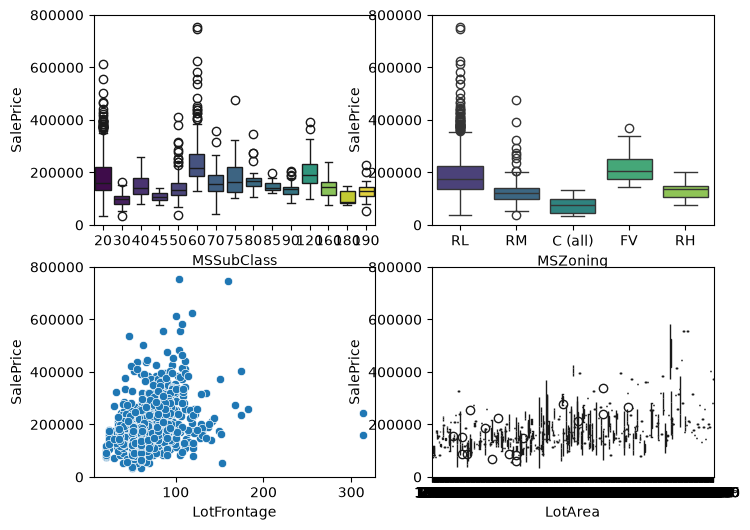

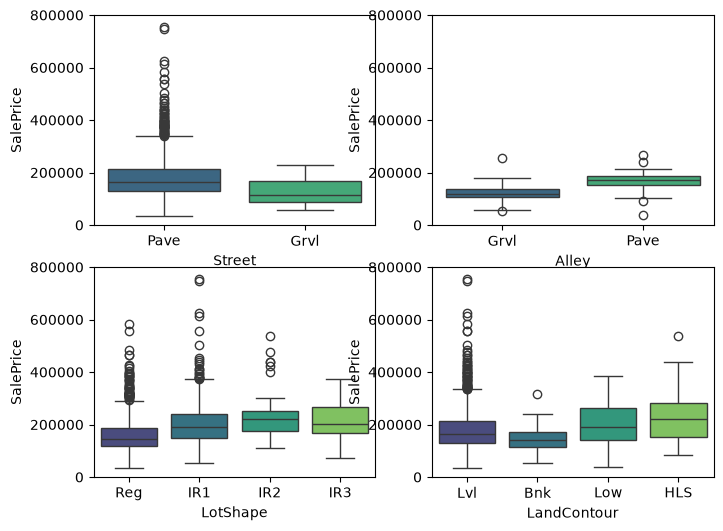

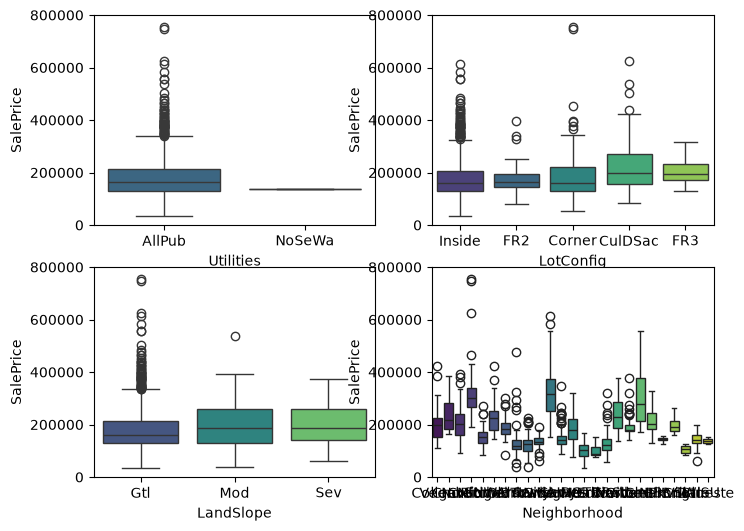

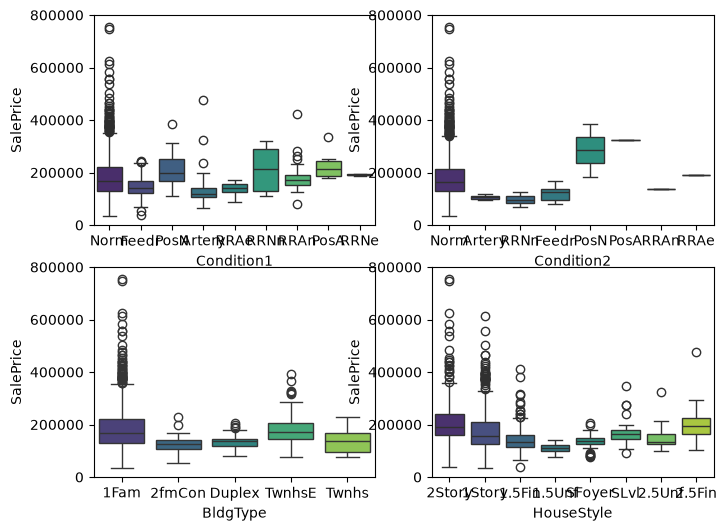

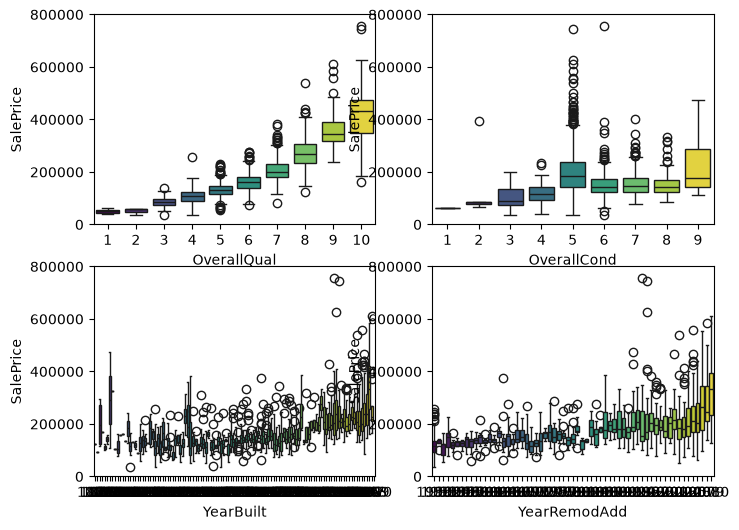

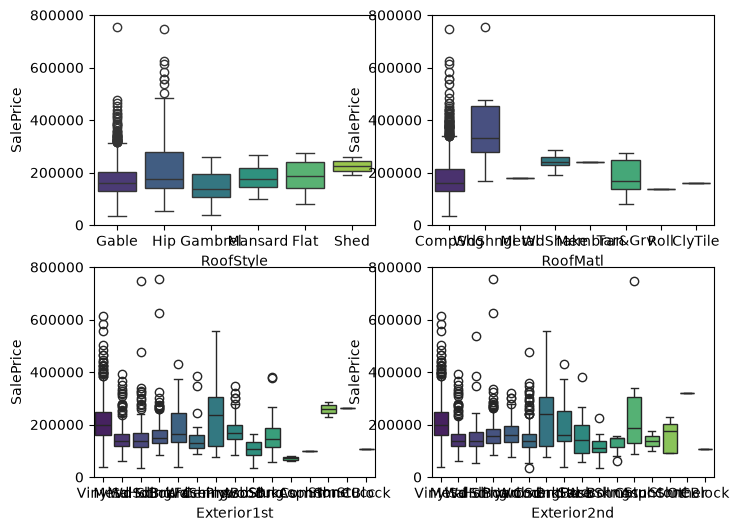

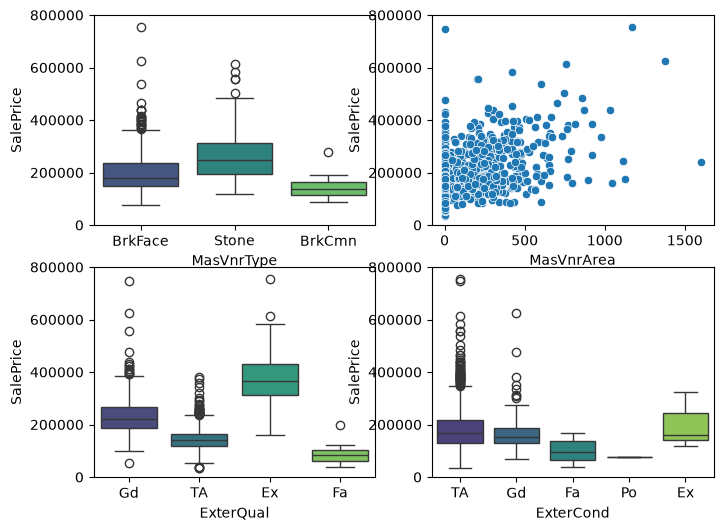

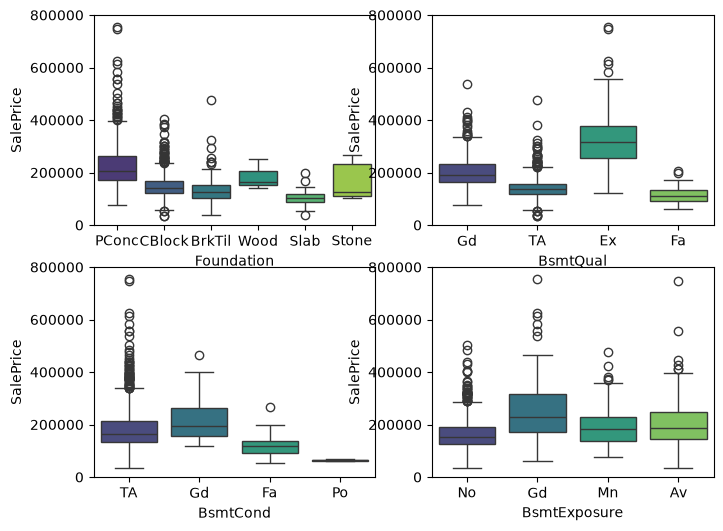

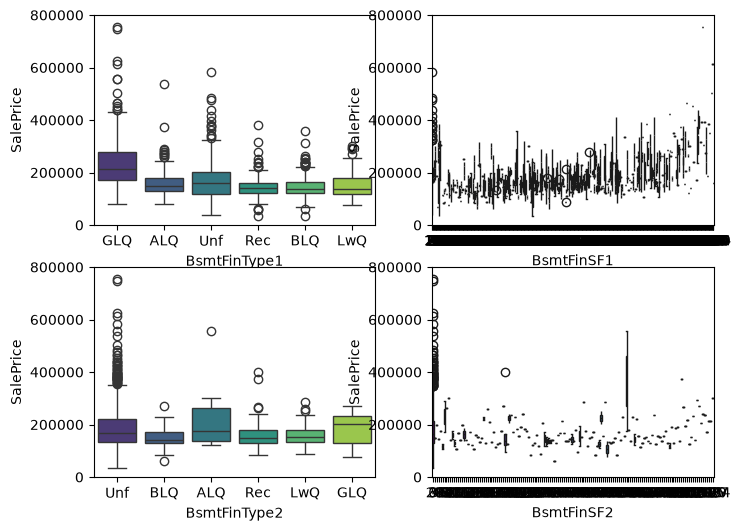

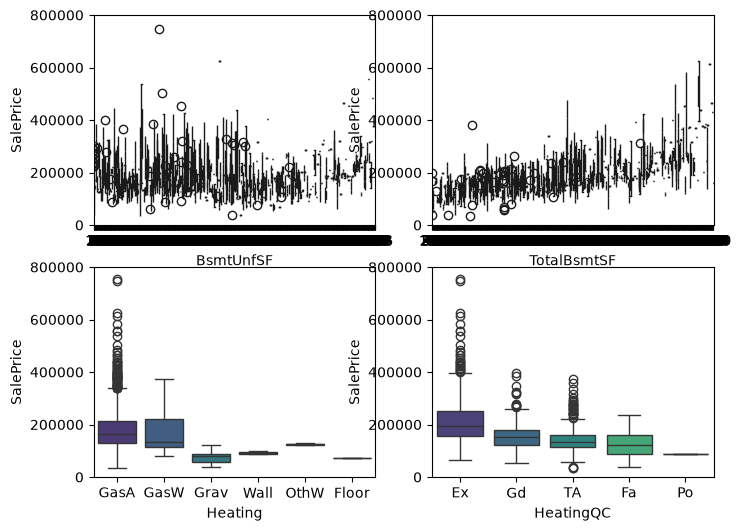

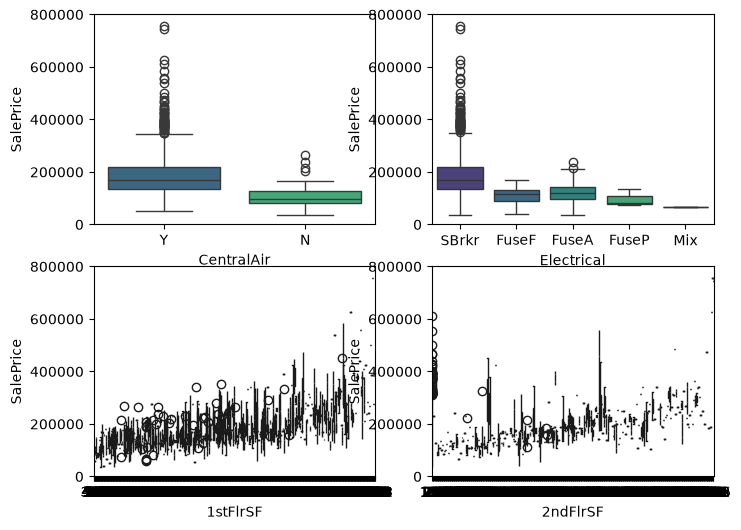

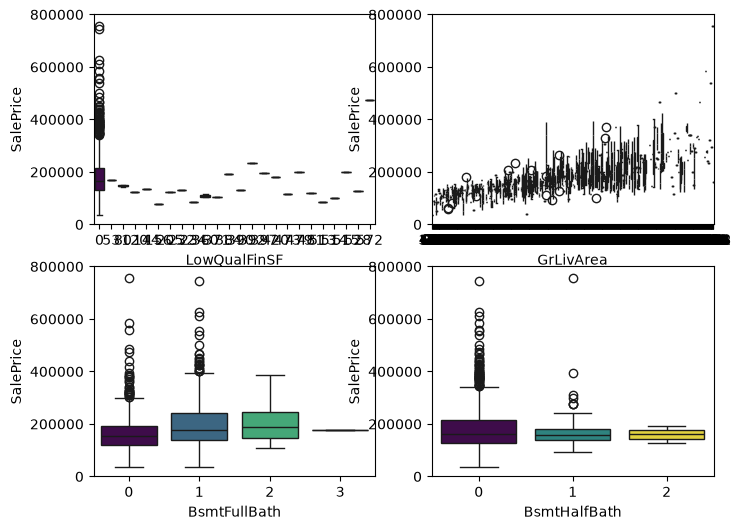

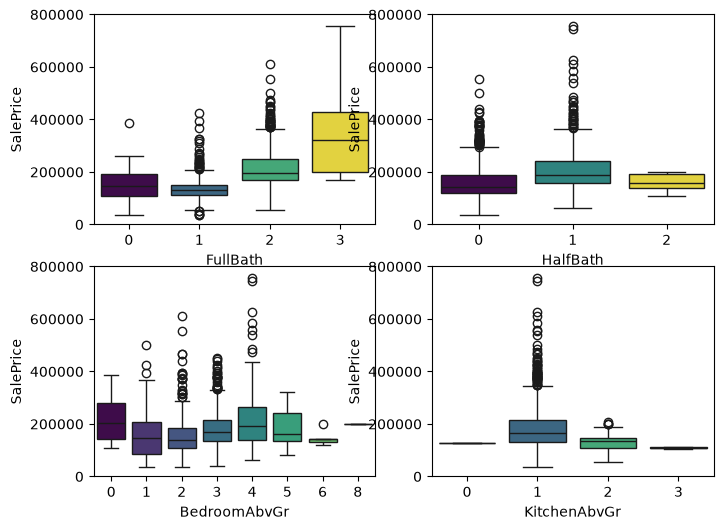

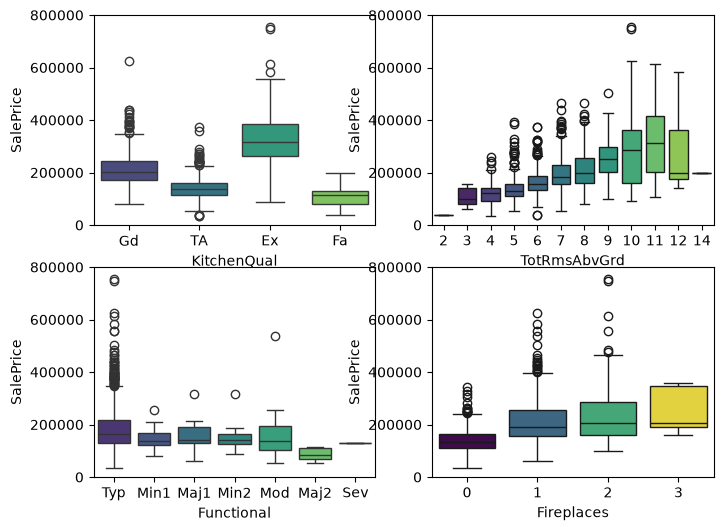

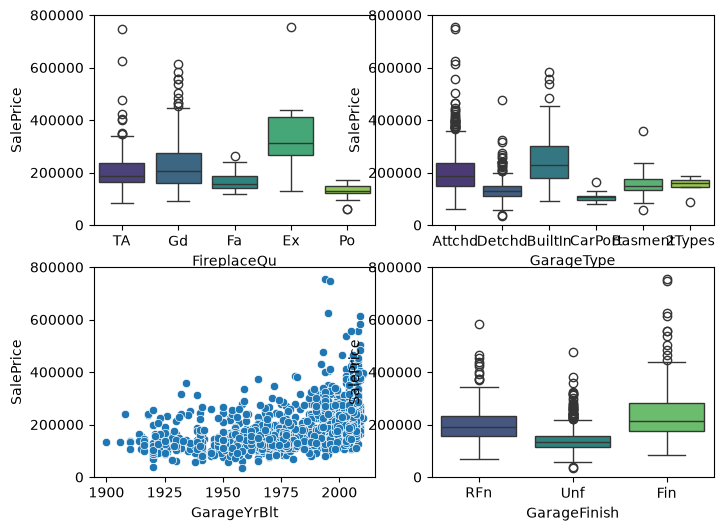

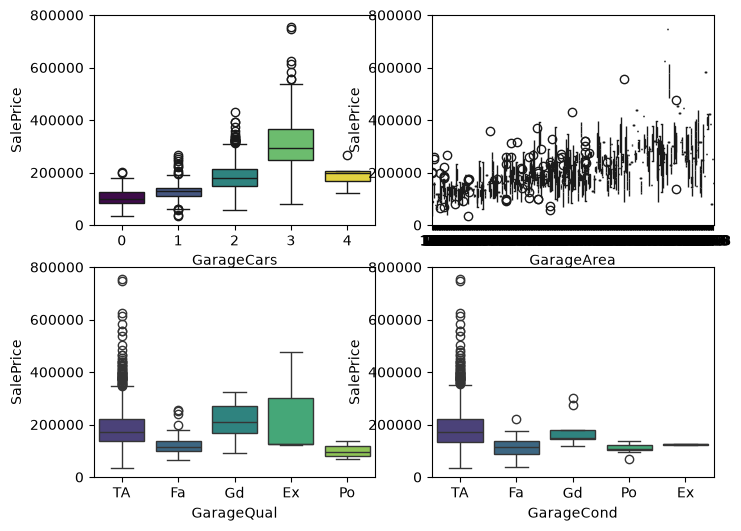

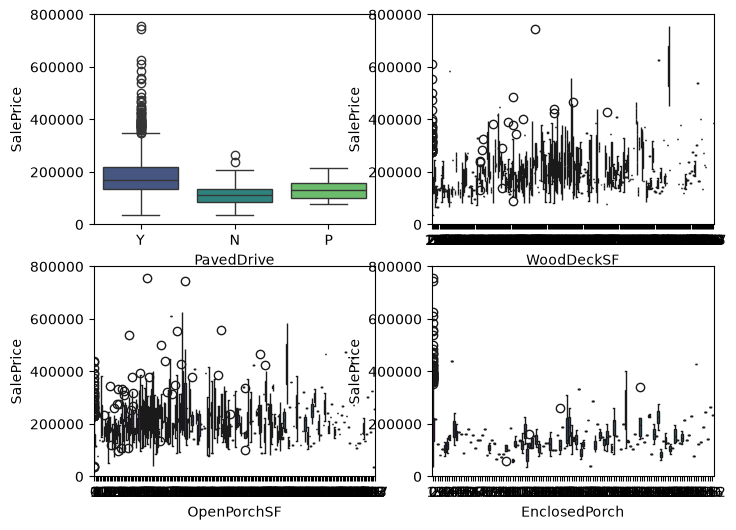

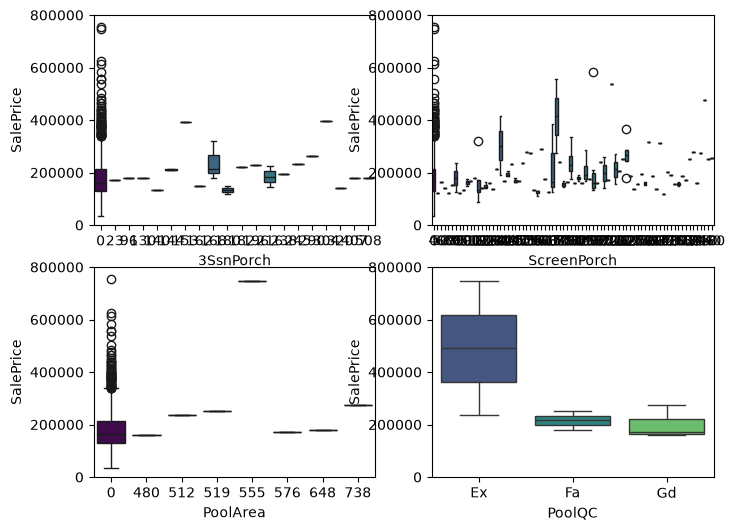

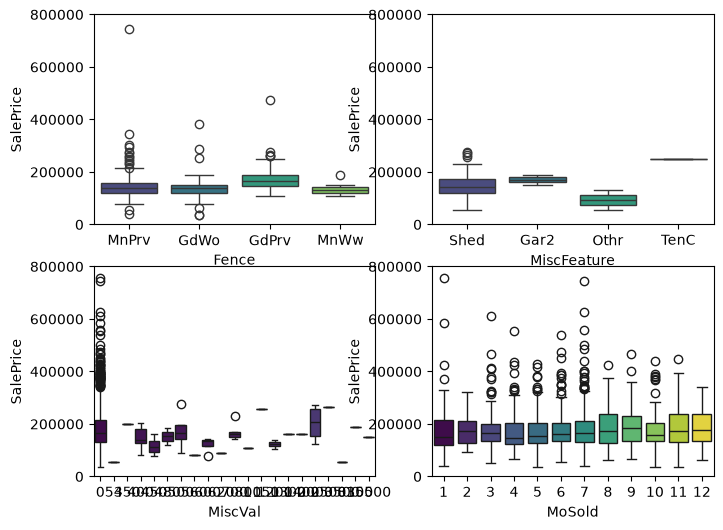

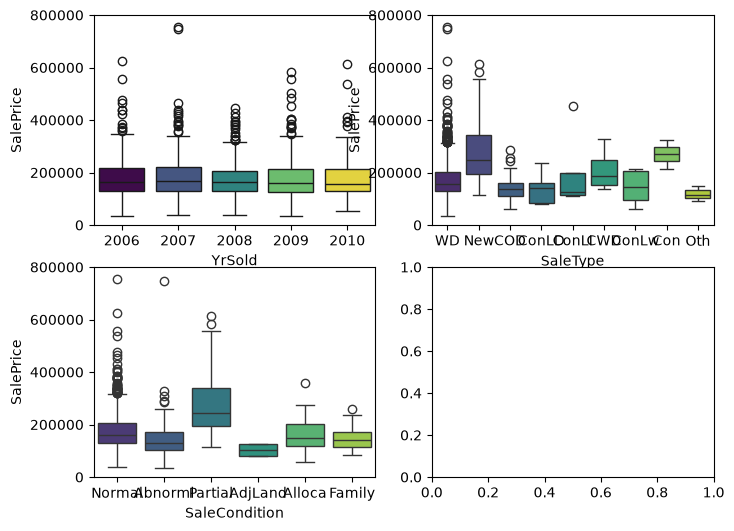

In [4]:
float_cols = X.select_dtypes(include='floating').columns
other_cols = X.columns.difference(float_cols)
print(len(float_cols))
print(len(other_cols))

plot_feat = X.columns

nite = len(plot_feat) // 4
if len(plot_feat) % 4 != 0:
    nite += 1

for ite in range(nite):
    f, axes = plt.subplots(2, 2, figsize=(8, 6))
    for ite2 in range(4):
        idx = ite * 4 + ite2
        if idx < len(plot_feat):
            feat_name = plot_feat[idx]
            ax = axes[ite2 // 2, ite2 % 2]
            data = pd.concat([y, X[feat_name]], axis=1)
            if feat_name in float_cols:
                sns.scatterplot(x=feat_name, y="SalePrice", data=data, ax=ax)
            else:
                sns.boxplot(x=feat_name, y="SalePrice", data=data, ax=ax, hue=feat_name, palette="viridis", dodge=False, legend=False)
            ax.set(ylim=(0, 800000))


#### Correlation matrix
Get correlation between features and between features and target. Usefull for selecting features.

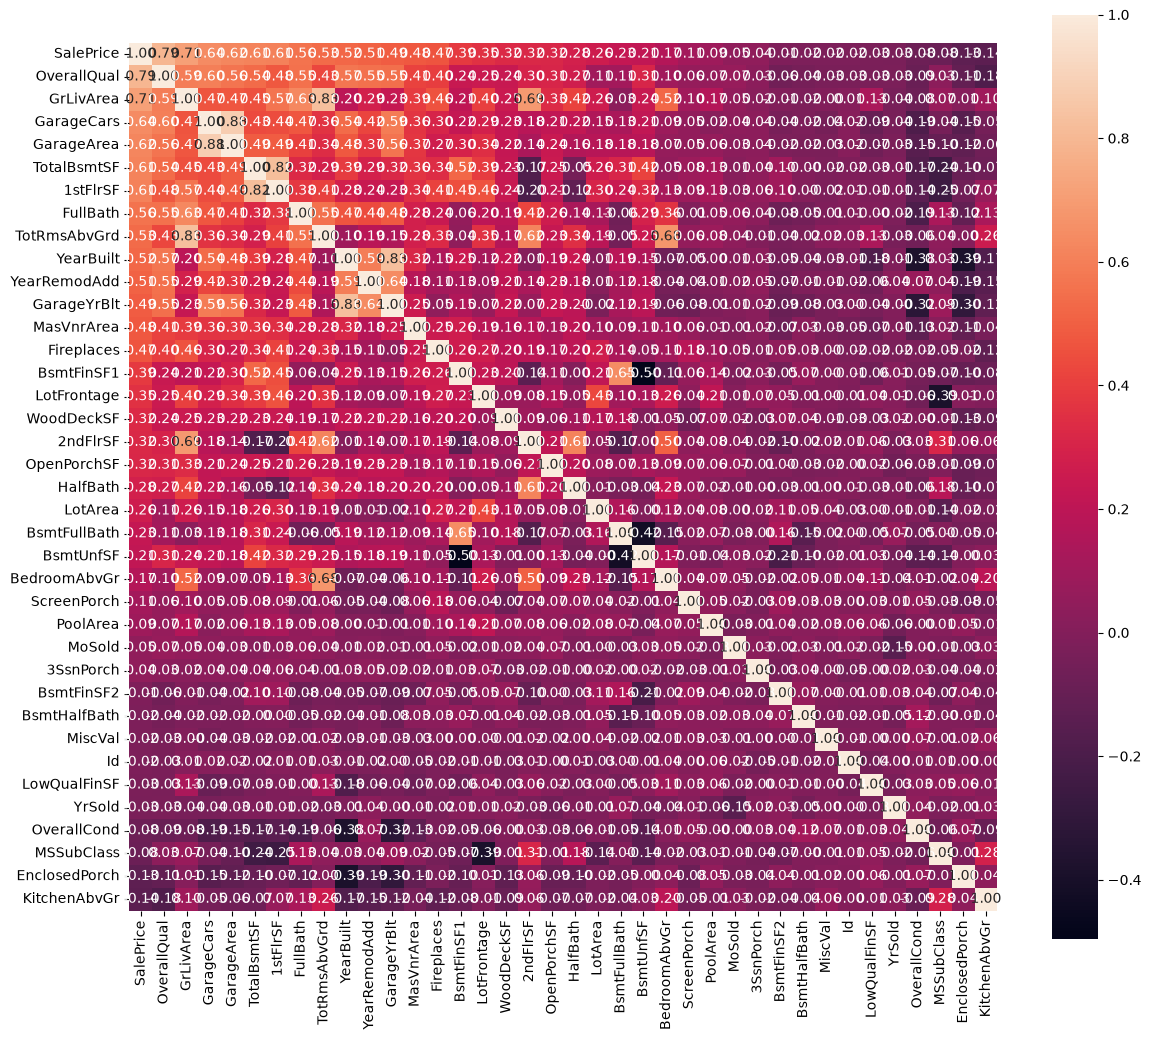

In [5]:
train_only_num = init_train.select_dtypes('number')
corrmat = train_only_num.corr()

n_cols = len(train_only_num.columns)
cols_corr = corrmat.nlargest(n_cols, 'SalePrice')['SalePrice'].index

fig, ax = plt.subplots(figsize=(14, 12))
zoomed_hm = sns.heatmap(corrmat.loc[cols_corr, cols_corr], cbar=True, annot=True, ax=ax, square=True, fmt='.2f', yticklabels=cols_corr.values, xticklabels=cols_corr.values)


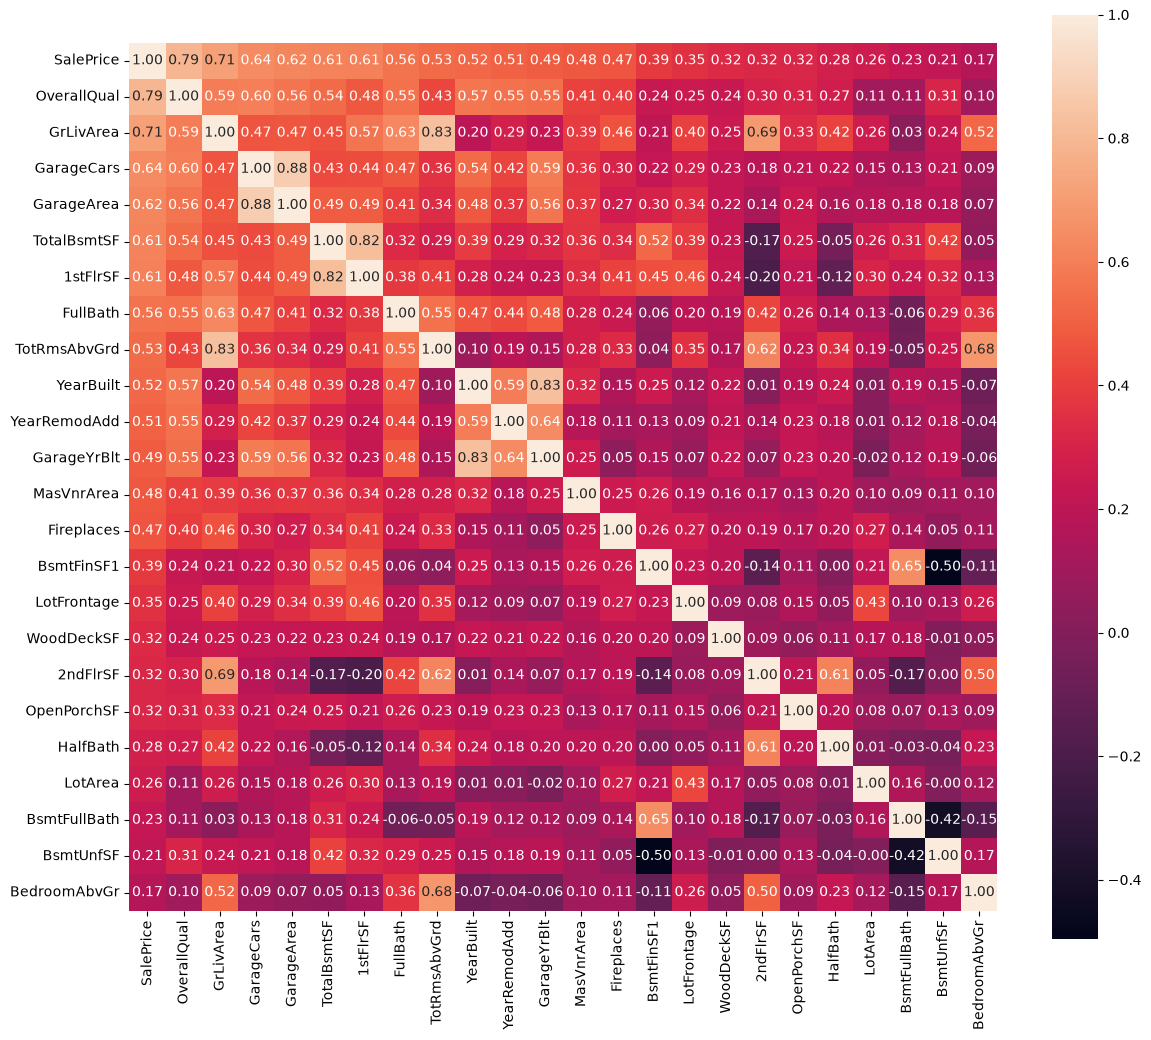

In [6]:
n_cols = 24
cols_corr = corrmat.nlargest(n_cols, 'SalePrice')['SalePrice'].index

fig, ax = plt.subplots(figsize=(14, 12))
zoomed_hm = sns.heatmap(corrmat.loc[cols_corr, cols_corr], cbar=True, annot=True, ax=ax, square=True, fmt='.2f', yticklabels=cols_corr.values, xticklabels=cols_corr.values)


Some strong correlations with target and some of the features also show correlation, maybe there is multicollinearity there, making some features repetitive
#### Zooming in the greater correlations by selecting less columns
The first 23 columns show better correlation with target (target not included because it doesn't really count), the other show very little correlation.
The first 10 show a correlation > 0.5

#### Using scatter plots with the most correlated to get better insight.
We remove GarageArea (already represented by GarageCars), AstFlrSF (twin with TotalBsmtSF) and TotRmsAbvGrd (twin with GrLivArea).

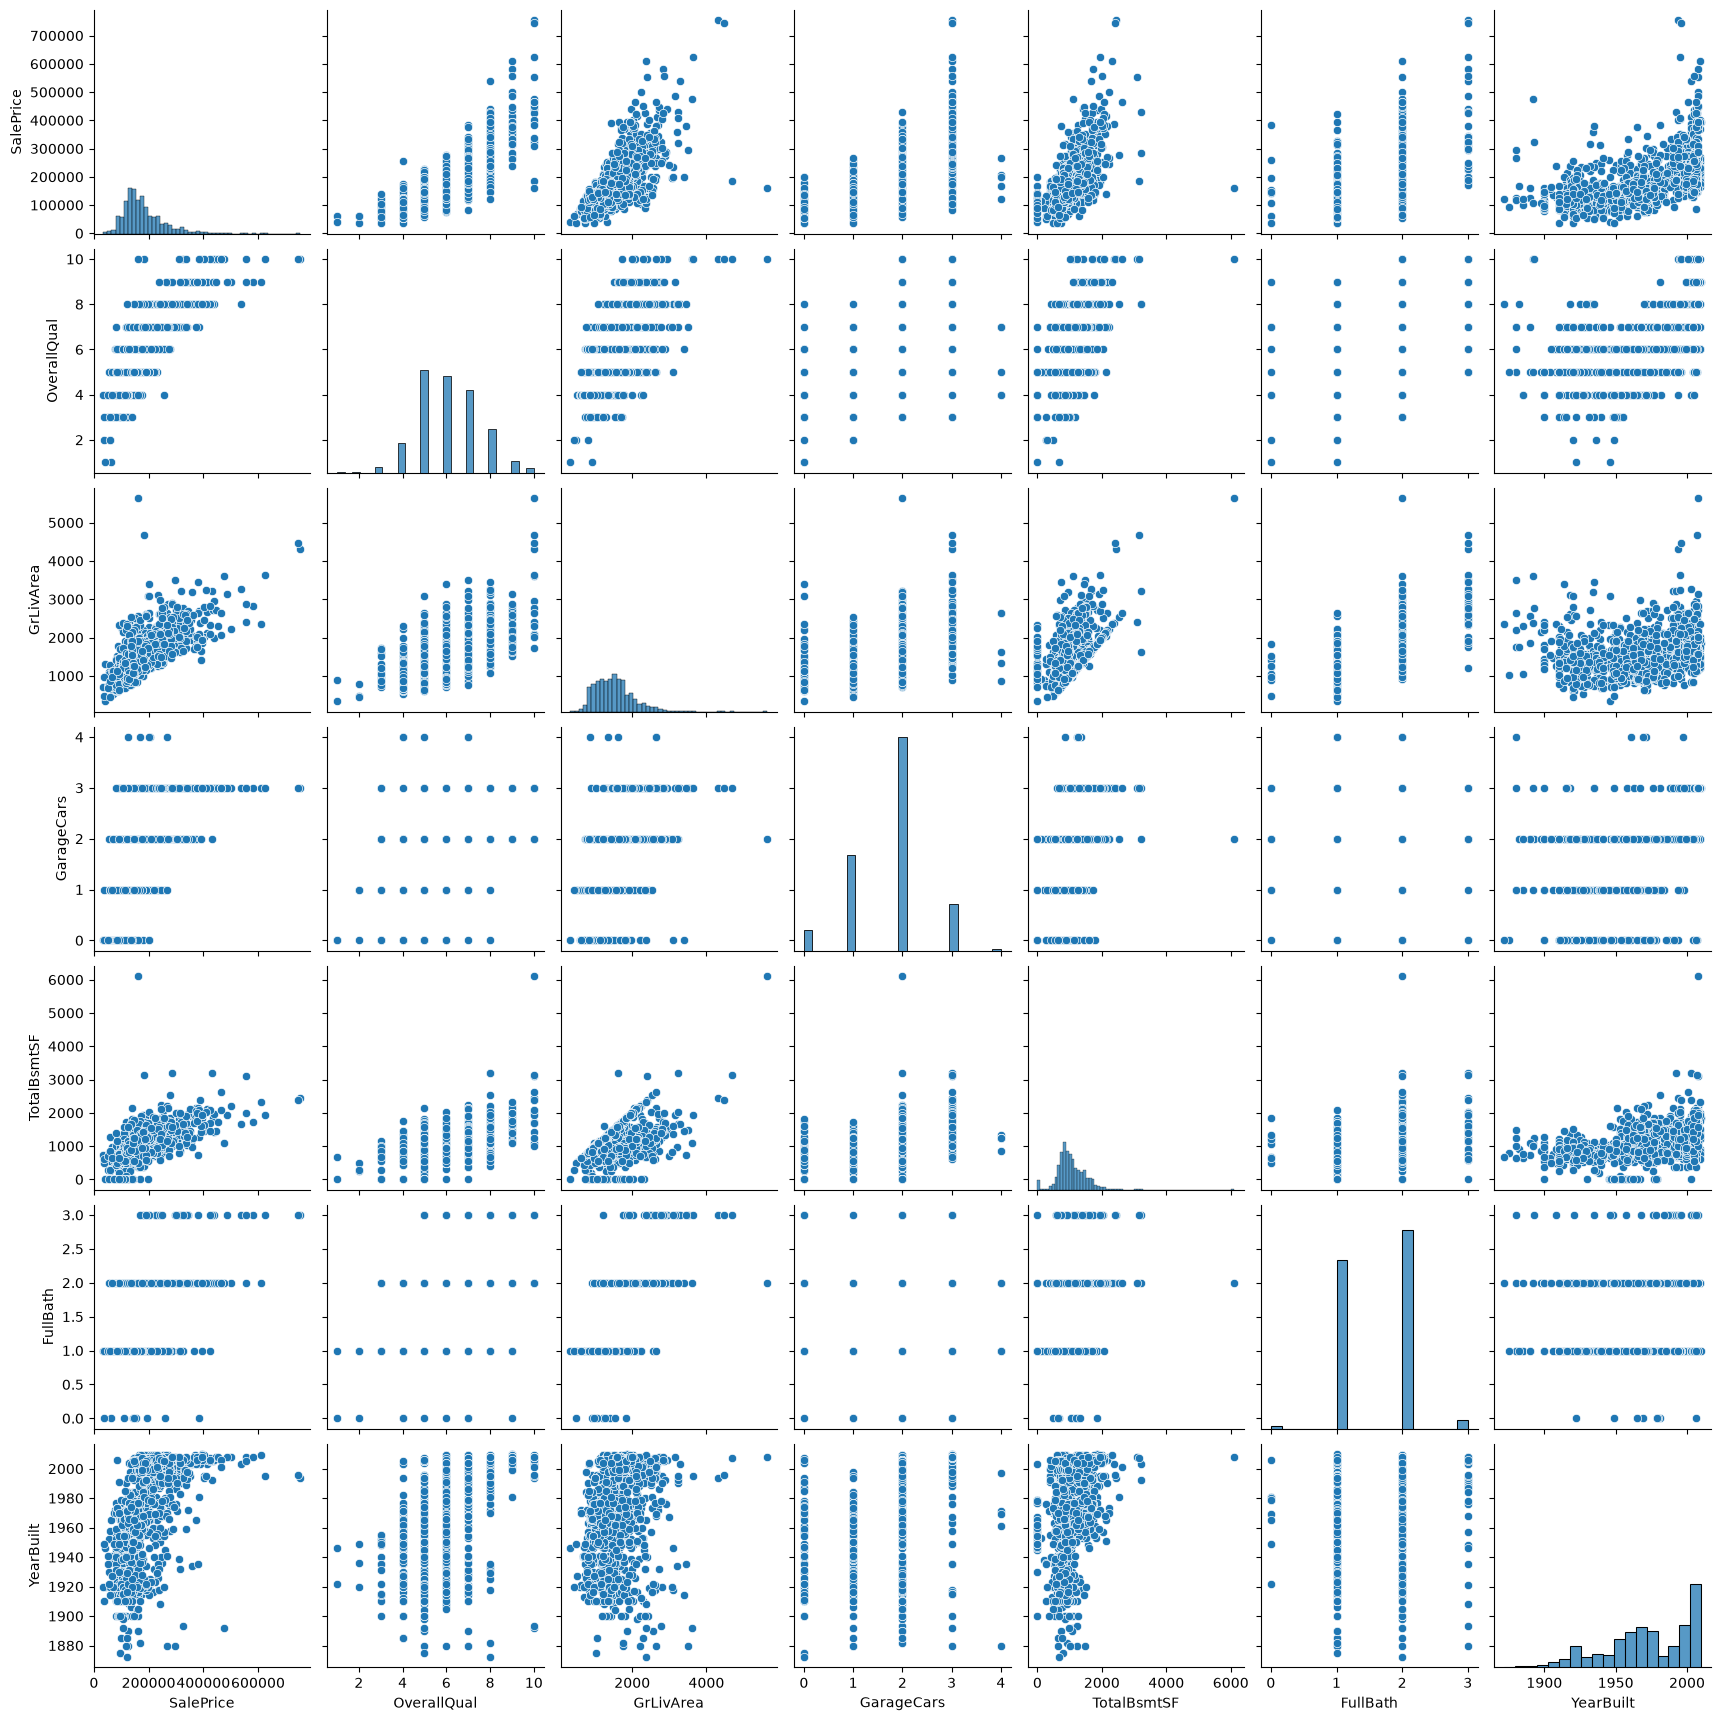

In [7]:
cols_scatter = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(train_only_num[cols_scatter], height = 2.5)

## Cleaning the data

#### Missing data

In [8]:
missing_total = init_train.isnull().sum().sort_values(ascending=False)
missing_percent = (init_train.isnull().sum()/init_train.isnull().count()*100).sort_values(ascending=False)
stats_missing = pd.concat([missing_total, missing_percent], axis=1, keys=['Total', 'Percent'])
stats_missing.head(20)

,Total,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


We remove the PoolQC, MiscFeature, Alley, Fence, MasVnrType, FireplaceQu and LotFrontage columns as they contain a lot of missing values. These don't seem very interesting so we can afford not using them.

In a first time we can also remove the Garage and Bsmt variables as we already have Garage and Bsmt variable that strongly impact our target. We could also analyse multicollinearity between Garage and Bsmt variables to make sure having only the main one representing the rest is a proper method.

MasVnrType and Area do not seem really important as they are + they are quite correlated with OverallQual and YearBuilt so we don't lose too much information by not considering them

For electrical, only 1 missing, so we just remove the row.

##### We apply the analysis we did on missing data

In [17]:
train = init_train.drop(stats_missing[stats_missing.Total > 1].index, axis=1)
train = train.drop(train.loc[train["Electrical"].isnull()].index, axis=0)
print(f"Number of remaining missing values : {train.isnull().sum().sum()}")

Number of remaining missing values : 0


#### Study of outliers
Univariate analysis : which row show a target value away from the center of the normal distribution of the values after they are standardized. (Target may not be exactly distributed normally)

In [18]:
# Standardisation :
std_prices = pd.Series(StandardScaler().fit_transform(train["SalePrice"].values[:, np.newaxis]).flatten(), index=train.index)
std_df = pd.concat([train.SalePrice, std_prices], axis=1).sort_values(by="SalePrice", ascending=True)
print(std_df.head(10))
print(std_df.tail(10))

      SalePrice         0
495       34900 -1.838208
916       35311 -1.833034
968       37900 -1.800444
533       39300 -1.782821
30        40000 -1.774010
710       52000 -1.622956
1337      52500 -1.616662
705       55000 -1.585192
1325      55000 -1.585192
812       55993 -1.572692
      SalePrice         0
798      485000  3.827581
178      501837  4.039522
769      538000  4.494736
440      555000  4.708730
1046     556581  4.728631
803      582933  5.060346
898      611657  5.421919
1169     625000  5.589879
1182     745000  7.100420
691      755000  7.226298


The 2 last value are really out of range (7 sigma), we keep them but they may cause some issues

Bivariate analysis :


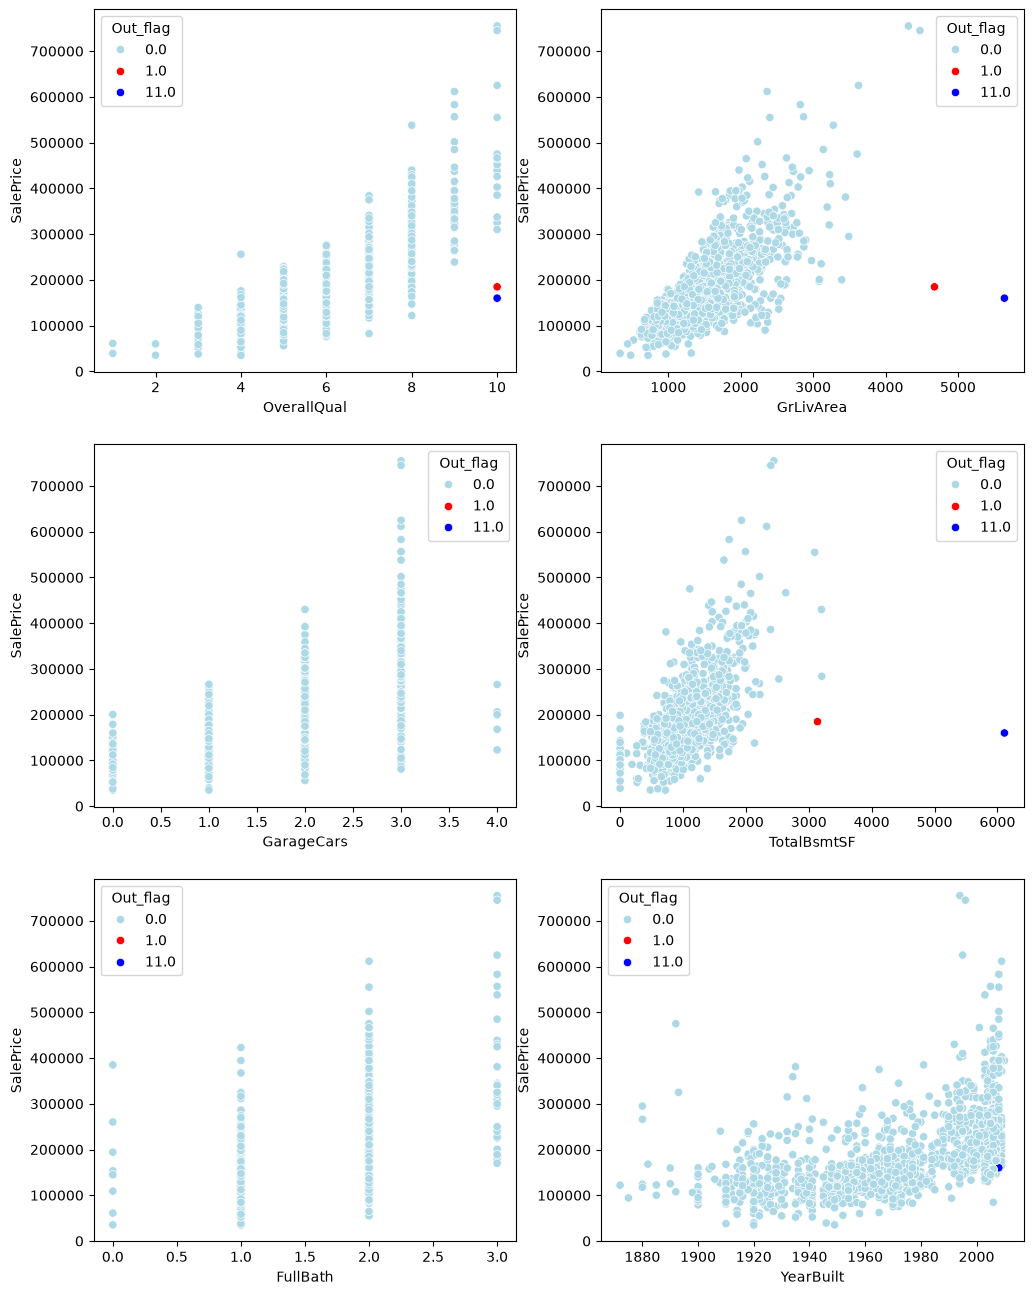

In [19]:
cols_outliers = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
data = train[["SalePrice"]+cols_outliers]

# Serch of the outliers' index
# print(train[["SalePrice", "GrLivArea"]].sort_values(by="GrLivArea", ascending=False))
# print(train[["SalePrice", "TotalBsmtSF"]].sort_values(by="TotalBsmtSF", ascending=False))
data["Out_flag"] = np.zeros(len(data))
data.loc[523, "Out_flag"] = 1
data.loc[1298, "Out_flag"] = 11
palette = {0: "lightblue", 1: "red", 11: "blue"}

fig, axes = plt.subplots(3, 2, figsize=(12, 16))
for ite_feat, feat in enumerate(cols_outliers):
    ax = axes[ite_feat//2, ite_feat%2]
    sns.scatterplot(data, x=feat, y="SalePrice", ax=ax, hue="Out_flag", palette=palette)

We do not consider the 2 outliers found with GrLivArea. Extreme values of SalePrice show 2 outliers but they seem to follow the trends in the graphs so it seems it represents properly the variation

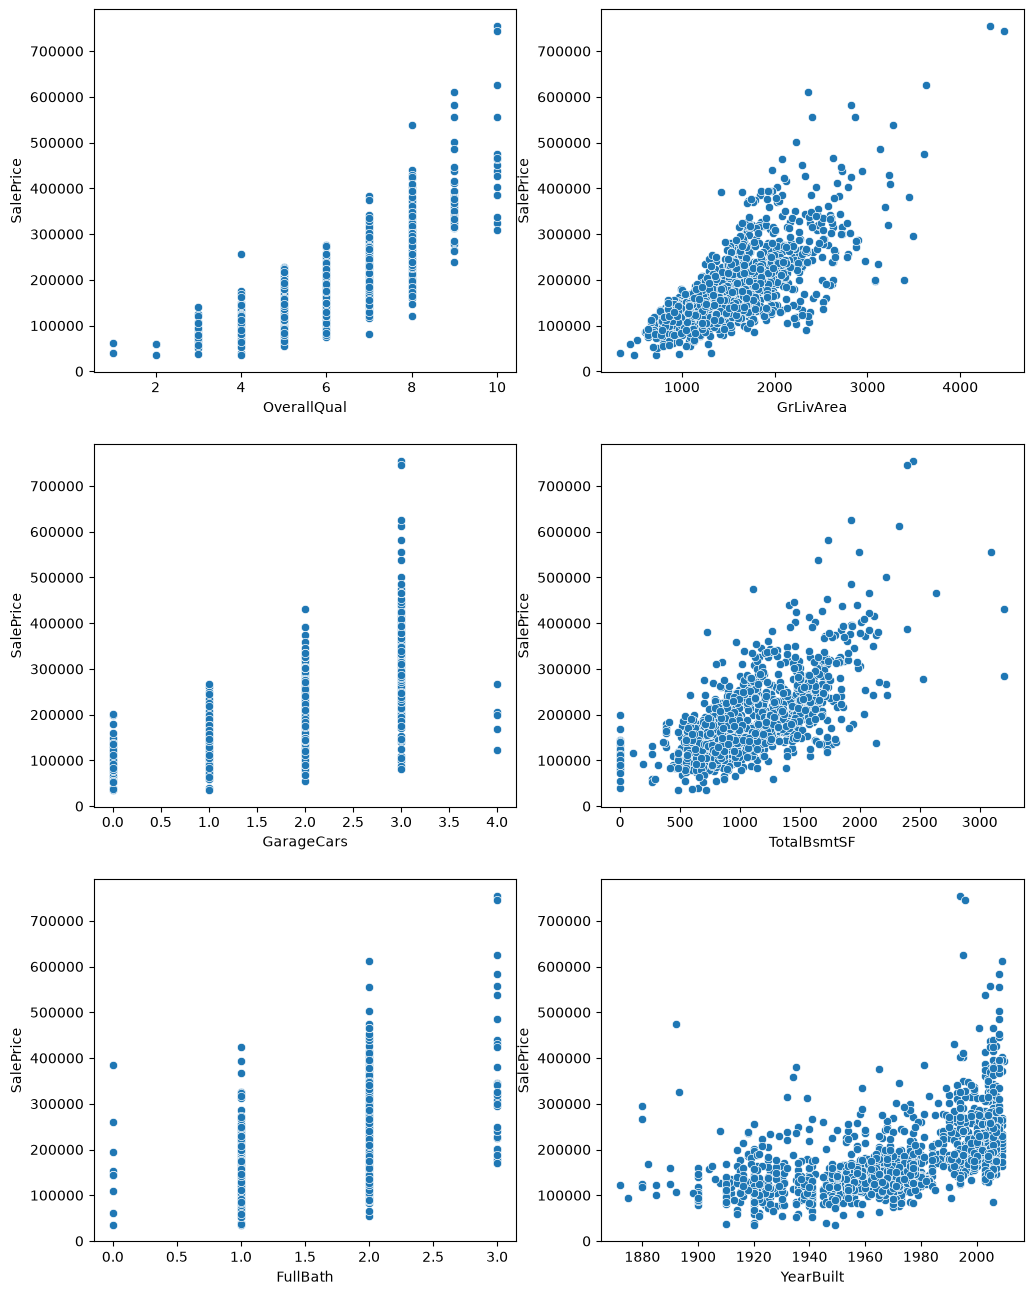

In [20]:
train = train.drop([523, 1298], axis=0)
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
for ite_feat, feat in enumerate(cols_outliers):
    ax = axes[ite_feat//2, ite_feat%2]
    sns.scatterplot(train, x=feat, y="SalePrice", ax=ax)

In [21]:
# Regarder si erreurs de frappe (fuzzy search et tout)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)


In [72]:
# Impute : G﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿rer donn﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿es manquantes (supprimer, remplacer, etc)
# .dropna() (drop lignes)
# .dropna(axis=1) (drop colonnes)
# .fillna(choix : 0.0, df['col'].mean, .meadian, .mode, method='bfill'/'ffill', interpolation)

# Parsing/Analysing dates + validation of the date format, many mistakes can happen there
# df['parsed_date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y') -> Attention au format
# V﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿rifier que mois et jours de sont pas confondus :
#  day_of_mounth = df['parsed_date'].dt.day
#   -> on doit ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿tre entre 1 et 31, - de 31 que le reste, distri ~homog﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ne si indep du jour (ev naturels, ...)
# date_length = df.Date.str.len()
# date_length.value_counts()

# Correct : Corriger les potentielles erreurs de frappe

# Faire attention aux erreurs d'encodage des fichiers

# Encoder -> Possible d'encoder puis normaliser ?

# Normaliser/scaler


## Engineering features

## Training and testing the model